# imports and data loading

In [1]:
from model_pipelines.xgb_classifier import *
from model_pipelines.check_calibration import *
from model_pipelines.auxilliary_functions import *
from eda.scoring_function import score_model_optimal_k
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from pathlib import Path

In [2]:
# do not change project up to project root
PROJECT_FOLDER_NAME = "-Cost-Sensitive-Predictive-Modeling"
current_path = Path(os.getcwd()).resolve()
project_root = Path(*current_path.parts[:current_path.parts.index(PROJECT_FOLDER_NAME) + 1])
#======== run variables ======================================
EXP_NAME = "xgb_common" # set run name
EXP_DIR = project_root / "experiment_results" / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)
#filenames to save output
FILE_SUBSETS_RESULTS_DF= EXP_DIR / "all_subsets_results_before_tuning.csv"
FILE_ALL_SUBSETS_DICT= EXP_DIR / "all_subsets_dict.json"
FILE_BEST_AFTER_TUNING = EXP_DIR / "top10_subsets_hyperparam_tuning_dict.json"
FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_mulitrun_check_dict.json"
FILE_CV_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_cv_dict.json"
PLOT_DIR = EXP_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
# Check of directories
print(f" Root: {project_root}")
print(EXP_DIR)

 Root: C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\xgb_common


In [3]:
#load data (full training data)
y=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")
x=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")

In [4]:
# load a dict of all columns selected (another dict may need to be passed)
selected_cols_dict=joblib.load("C:\\Users\\andrz\\Downloads\\selected_features_dictionary.joblib")


In [5]:
#extract the right subset of columns (3 options - for all features, for model features, for statistical features, select one and comment out the others)
# selected_second_level_subset=selected_cols_dict['MI'] #for one statistical method, just change the key if needed
# selected_second_level_subset=unpack_whole_feature_dict(selected_cols_dict,extract='common') # for features found by all methods, if all features found by different methods, use extract='all_found'
selected_second_level_subset=unpack_model_feature_dict(selected_cols_dict,'xgb',extract='common') # for selecting the features found by all xgb (or possibly rf - change second argument) models, extract works as in the previous example

In [6]:
x_t,x_tst,y_t,y_tst=train_test_split(x.loc[:,selected_second_level_subset],y,test_size=0.2,random_state=7)

# check all combinations of the selected features for one configuration of xgb model

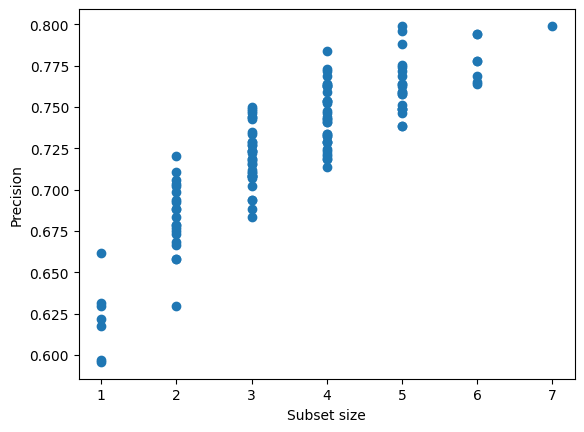

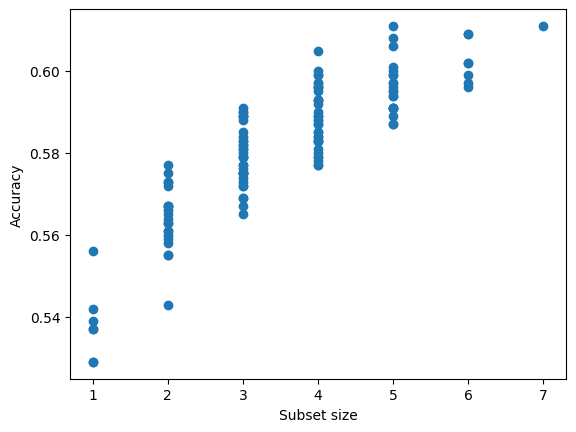

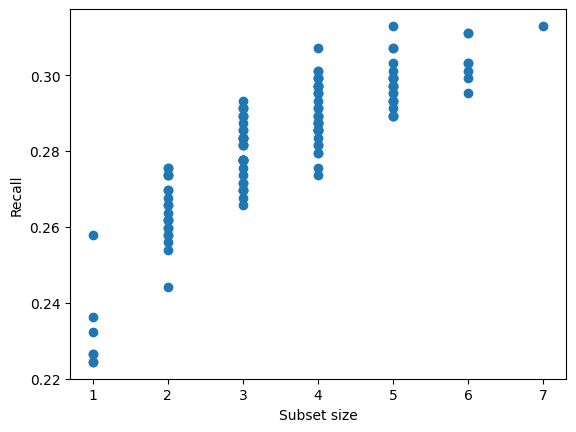

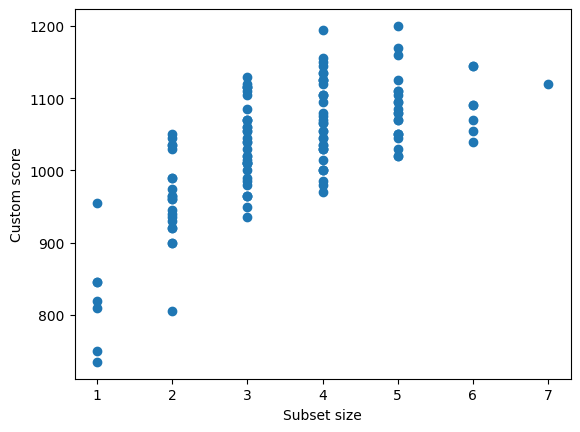

In [6]:
best_model,best_ft,df,all_subsets=train_model_all_combinations(x_t,y_t,x_tst,y_tst,max_subset=selected_second_level_subset,return_metrics=True)

In [17]:
#reload if needed:
df=pd.read_csv(FILE_SUBSETS_RESULTS_DF,index_col='Subset index')
with open(FILE_ALL_SUBSETS_DICT, 'r') as file:
    all_subsets = json.load(file)
all_subsets = {int(k): v for k, v in all_subsets.items()}

In [18]:
df=df.sort_values(by="Precision", ascending=False)
df_top10_prec=df.head(10)

print(df_top10_prec)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
46                  1200.0   0.798995     0.611  0.312992
126                 1120.0   0.798995     0.611  0.312992
61                  1170.0   0.795918     0.608  0.307087
110                 1145.0   0.793970     0.609  0.311024
62                  1145.0   0.793970     0.609  0.311024
54                  1160.0   0.787879     0.606  0.307087
29                  1195.0   0.783920     0.605  0.307087
125                 1090.0   0.777778     0.602  0.303150
94                  1090.0   0.777778     0.602  0.303150
58                  1110.0   0.775510     0.600  0.299213


In [8]:
df=df.sort_values(by="Custom Score", ascending=False)
df_top10_score=df.head(10)

print(df_top10_score)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
90                  1200.0   0.798995     0.611  0.312992
112                 1195.0   0.783920     0.605  0.307087
114                 1170.0   0.795918     0.608  0.307087
58                  1160.0   0.787879     0.606  0.307087
91                  1155.0   0.772727     0.600  0.301181
50                  1150.0   0.768844     0.599  0.301181
122                 1145.0   0.793970     0.609  0.311024
42                  1145.0   0.771574     0.599  0.299213
94                  1145.0   0.793970     0.609  0.311024
84                  1135.0   0.763819     0.597  0.299213


In [9]:
df.to_csv(FILE_SUBSETS_RESULTS_DF, index=True)
save_dict_to_json(all_subsets,FILE_ALL_SUBSETS_DICT)


Successfully saved data to C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\xgb_common\all_subsets_dict.json


# for top 10 feature subsets conduct hyperparameter tuning, at one split.

In [19]:
#initialize a dict for the results of hyperparameter tuning for top 10 subsets
top10_hyperparameter_tuning_result_dict = {
    idx: {}
    for idx in df_top10_prec.index
}

In [20]:
for ind in df_top10_prec.index:
    print("=========================================")
    print(f"subset {ind}: {all_subsets[ind]}")
    print("=========================================")
    best_c_hyperparams,best_p_hyperparams=final_xgb_hyperparameter_grid_optimizer(x_t.loc[:,all_subsets[ind]],y_t,x_tst.loc[:,all_subsets[ind]],y_tst)
    xgb=XGBClassifier(max_depth=best_c_hyperparams['max_depth'],n_estimators=best_c_hyperparams['n_estimators'],learning_rate=best_c_hyperparams['lr'],random_state=7)
    xgb.fit(x_t.loc[:,all_subsets[ind]],y_t)
    y_pred_proba=xgb.predict_proba(x_tst.loc[:,all_subsets[ind]])[:,1]
    best_score,best_threshold, best_k, best_fp, best_tp=score_model_optimal_k(y_tst,y_pred_proba,len(all_subsets[ind]),keep_fp_tp=True,max_k=200,feature_penalty=40)
    top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']=best_c_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_p_hyperparams']=best_p_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_threshold']=best_threshold
    top10_hyperparameter_tuning_result_dict[ind]['best_score']=best_score
    top10_hyperparameter_tuning_result_dict[ind]['best_fp']=best_fp
    top10_hyperparameter_tuning_result_dict[ind]['best_tp']=best_tp
    top10_hyperparameter_tuning_result_dict[ind]['subset_list']=all_subsets[ind] # added for easier reloading
    print("=======================================")
    print(f"Score for subset {all_subsets[ind]}")
    print(f"best score: {best_score}, best threshold: {best_threshold}, fp:{best_fp}, tp:{best_tp}")
    print(f"best custom hyperparameters: {best_c_hyperparams}")
    print(f"best precision hyperparameters: {best_p_hyperparams}")
    print("=======================================")
save_dict_to_json(top10_hyperparameter_tuning_result_dict,FILE_BEST_AFTER_TUNING)

subset 46: ['V342', 'V215', 'V380', 'V255', 'V160']
Score for subset ['V342', 'V215', 'V380', 'V255', 'V160']
best score: 1195, best threshold: 0.6695761680603027, fp:39, tp:159
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.1}
best precision hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.1}
subset 126: ['V342', 'V215', 'V380', 'V255', 'V191', 'V160', 'V176']
Score for subset ['V342', 'V215', 'V380', 'V255', 'V191', 'V160', 'V176']
best score: 1210, best threshold: 0.8695874214172363, fp:34, tp:166
best custom hyperparameters: {'max_depth': 3, 'n_estimators': 2000, 'lr': 0.1}
best precision hyperparameters: {'max_depth': 3, 'n_estimators': 2000, 'lr': 0.1}
subset 61: ['V215', 'V380', 'V255', 'V191', 'V160']
Score for subset ['V215', 'V380', 'V255', 'V191', 'V160']
best score: 1260, best threshold: 0.690162181854248, fp:36, tp:164
best custom hyperparameters: {'max_depth': 2, 'n_estimators': 500, 'lr': 0.1}
best precision hyperparameters: {'

TypeError: Object of type float32 is not JSON serializable

In [23]:
#create a df with the scores of the top10 subsets for easier further selection and get 4 top subset indices
auxliary_data = [
    {'ind': key, 'score': value['best_score']}
    for key, value in top10_hyperparameter_tuning_result_dict.items()
]
auxiliary_df = pd.DataFrame(auxliary_data)
auxiliary_df=auxiliary_df.sort_values(by="score", ascending=False)
top10_subset_indices=auxiliary_df.head(10).loc[:,"ind"].tolist()
# a dictionary for results of multi-split check
top10_multisplit_result_dict = {
    idx: {}
    for idx in top10_subset_indices
}

In [24]:
print(auxiliary_df)

   ind  score
2   61   1260
4   62   1250
1  126   1210
5   54   1205
9   58   1200
0   46   1195
3  110   1175
7  125   1175
8   94   1175
6   29   1165


In [25]:
for ind in top10_subset_indices:
    scores,precs=check_xgb_model_with_multi_split(x.loc[:, top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y,max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'], n_estimators=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['n_estimators'], learning_rate=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['lr'],n_checks=50,threshold=top10_hyperparameter_tuning_result_dict[ind]['best_threshold'])
    top10_multisplit_result_dict[ind]['scores']=scores
    top10_multisplit_result_dict[ind]['precs']=precs
    print(f"check done for index: {ind}")
# save_dict_to_json(top10_multisplit_result_dict,FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS)

no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives

C:\Users\andrz\AppData\Local\Temp\ipykernel_25620\2730525874.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


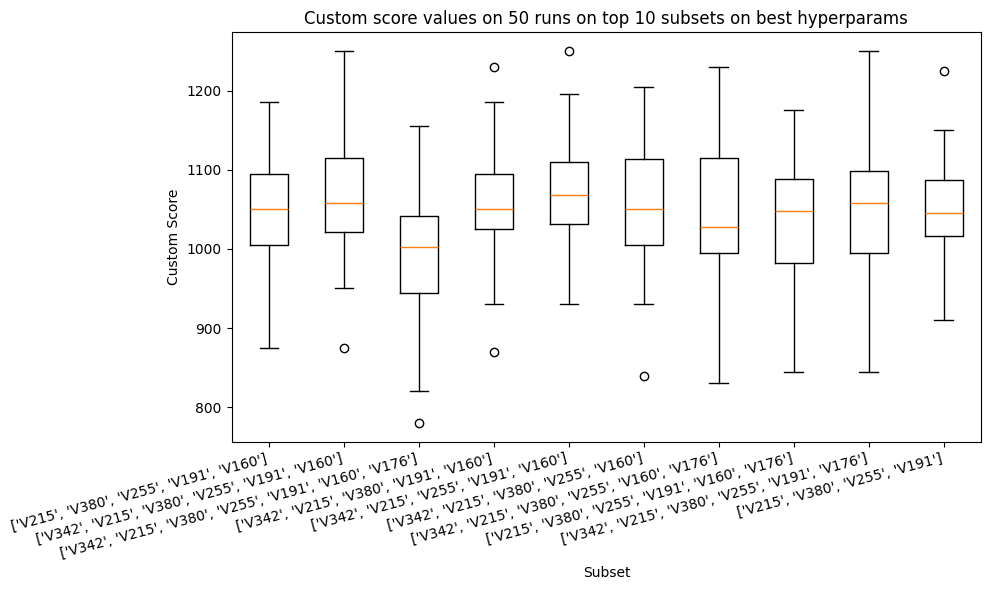

In [29]:
#plotting - custom scores (may be optional, but probably at this level the best will be selected manually)
data_to_plot = []
labels = []

for ind in top10_subset_indices:
    data_to_plot.append(top10_multisplit_result_dict[ind]['scores'])
    labels.append(str(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=labels)

plt.xlabel("Subset")
plt.ylabel("Custom Score")
plt.title("Custom score values on 50 runs on top 10 subsets on best hyperparams")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(Path(PLOT_DIR / "custom_score_50runs_boxplot.png"))
plt.show()

C:\Users\andrz\AppData\Local\Temp\ipykernel_25620\3926348023.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


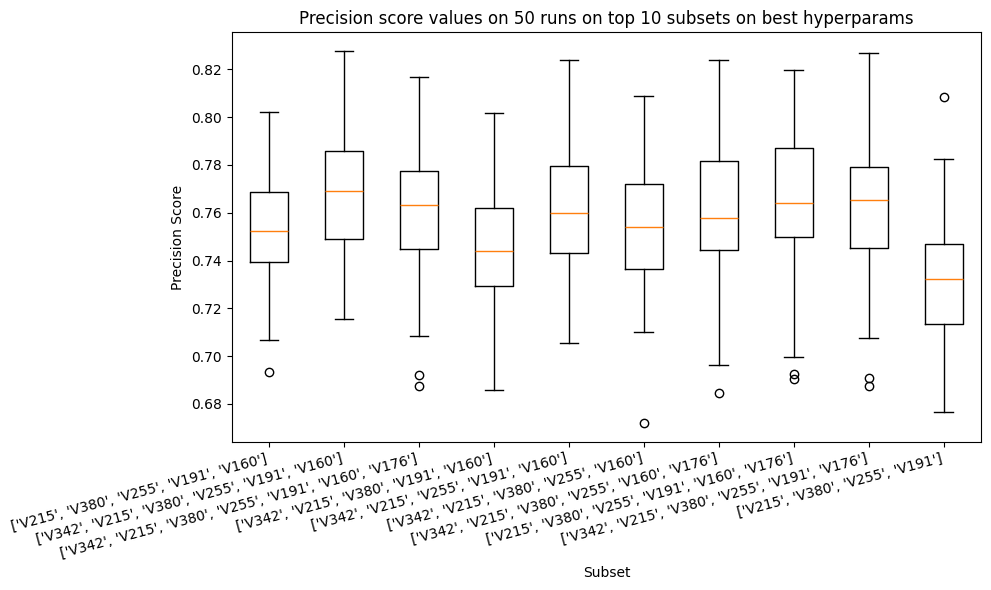

In [30]:
#plotting - precisions (may be optional, but probably at this level the best will be selected manually)
data_to_plot = []
labels = []

for ind in top10_subset_indices:
    data_to_plot.append(top10_multisplit_result_dict[ind]['precs'])
    labels.append(str(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=labels)

plt.xlabel("Subset")
plt.ylabel("Precision Score")
plt.title("Precision score values on 50 runs on top 10 subsets on best hyperparams")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(Path(PLOT_DIR / "precision_50runs_boxplot.png"))
plt.show()

In [31]:
top10_cv_result_dict={
    ind:{}
    for ind in top10_subset_indices
}
for ind in top10_subset_indices:
    print(f"checking cv score for subset: {top10_hyperparameter_tuning_result_dict[ind]['subset_list']}")
    model=XGBClassifier(max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'])
    all_y_test,all_y_prob=get_cv_calibration_predictions(model,x.loc[:,top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y)
    all_y_pred=(all_y_prob>score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))[1]).astype(int)
    print(precision_score(all_y_test,all_y_pred))
    top10_cv_result_dict[ind]["precision"]=precision_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["accuracy"]=accuracy_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["recall"]=recall_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["cv_custom_score"],top10_cv_result_dict[ind]["cv_best_threshold"]=score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']),keep_fp_tp=True)[:2]
    print(score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']),keep_fp_tp=True))
    print("===============================================")
# save_dict_to_json(top10_cv_result_dict,FILE_CV_TOP10_SUBSETS_RESULTS)

checking cv score for subset: ['V215', 'V380', 'V255', 'V191', 'V160']
0.7547547547547547
(5325, np.float32(0.67010397), 1000, 245, 755)
checking cv score for subset: ['V342', 'V215', 'V380', 'V255', 'V191', 'V160']
0.7582748244734202
(5165, np.float32(0.7171117), 998, 241, 757)
checking cv score for subset: ['V342', 'V215', 'V380', 'V255', 'V191', 'V160', 'V176']
0.7637637637637638
(5060, np.float32(0.7353764), 1000, 236, 764)
checking cv score for subset: ['V342', 'V215', 'V380', 'V191', 'V160']
0.7467467467467468
(5205, np.float32(0.63584626), 1000, 253, 747)
checking cv score for subset: ['V342', 'V215', 'V255', 'V191', 'V160']
0.7527527527527528
(5295, np.float32(0.6671628), 1000, 247, 753)
checking cv score for subset: ['V342', 'V215', 'V380', 'V255', 'V160']
0.7547547547547547
(5325, np.float32(0.6354043), 1000, 245, 755)
checking cv score for subset: ['V342', 'V215', 'V380', 'V255', 'V160', 'V176']
0.7497497497497497
(5050, np.float32(0.7144868), 1000, 250, 750)
checking cv sco

# before decision run calibration check

checking calibration for subset ['V215', 'V380', 'V255', 'V191', 'V160']
Bin  1 | n= 500 | mean_pred=0.248 | frac_pos=0.286
Bin  2 | n= 500 | mean_pred=0.301 | frac_pos=0.310
Bin  3 | n= 500 | mean_pred=0.342 | frac_pos=0.370
Bin  4 | n= 500 | mean_pred=0.387 | frac_pos=0.392
Bin  5 | n= 500 | mean_pred=0.439 | frac_pos=0.416
Bin  6 | n= 500 | mean_pred=0.497 | frac_pos=0.480
Bin  7 | n= 500 | mean_pred=0.559 | frac_pos=0.572
Bin  8 | n= 500 | mean_pred=0.632 | frac_pos=0.640
Bin  9 | n= 500 | mean_pred=0.721 | frac_pos=0.728
Bin 10 | n= 500 | mean_pred=0.856 | frac_pos=0.782


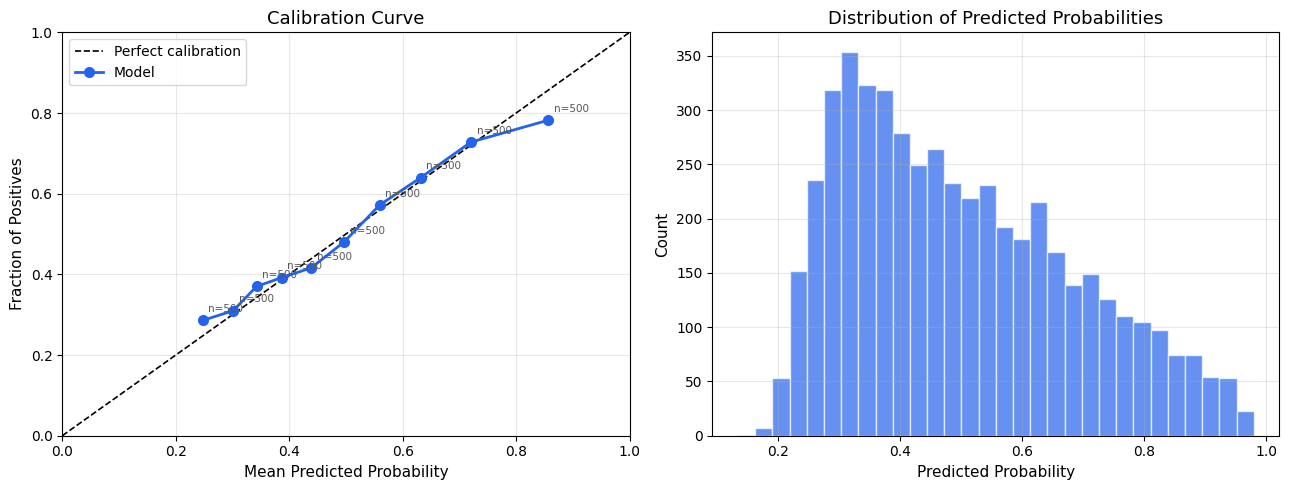

checking calibration for subset ['V342', 'V215', 'V380', 'V255', 'V191', 'V160']
Bin  1 | n= 500 | mean_pred=0.196 | frac_pos=0.254
Bin  2 | n= 500 | mean_pred=0.264 | frac_pos=0.316
Bin  3 | n= 500 | mean_pred=0.316 | frac_pos=0.362
Bin  4 | n= 500 | mean_pred=0.370 | frac_pos=0.396
Bin  5 | n= 500 | mean_pred=0.433 | frac_pos=0.442
Bin  6 | n= 500 | mean_pred=0.501 | frac_pos=0.474
Bin  7 | n= 500 | mean_pred=0.582 | frac_pos=0.566
Bin  8 | n= 500 | mean_pred=0.671 | frac_pos=0.652
Bin  9 | n= 500 | mean_pred=0.771 | frac_pos=0.728
Bin 10 | n= 500 | mean_pred=0.896 | frac_pos=0.786


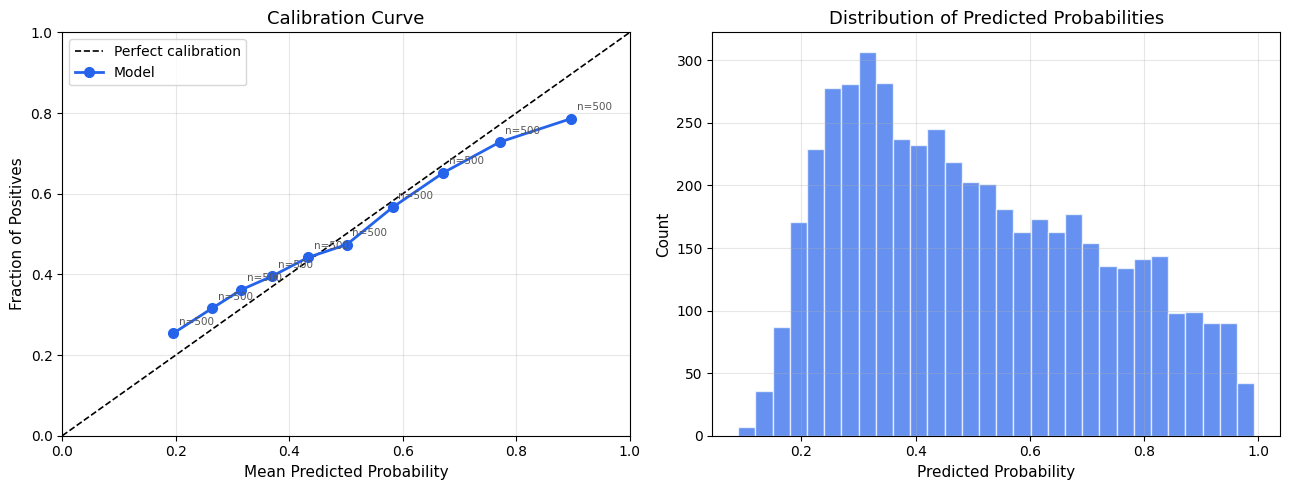

checking calibration for subset ['V342', 'V215', 'V380', 'V255', 'V191', 'V160', 'V176']
Bin  1 | n= 500 | mean_pred=0.173 | frac_pos=0.240
Bin  2 | n= 500 | mean_pred=0.244 | frac_pos=0.282
Bin  3 | n= 500 | mean_pred=0.303 | frac_pos=0.316
Bin  4 | n= 500 | mean_pred=0.364 | frac_pos=0.384
Bin  5 | n= 500 | mean_pred=0.429 | frac_pos=0.444
Bin  6 | n= 500 | mean_pred=0.505 | frac_pos=0.480
Bin  7 | n= 500 | mean_pred=0.593 | frac_pos=0.606
Bin  8 | n= 500 | mean_pred=0.686 | frac_pos=0.696
Bin  9 | n= 500 | mean_pred=0.790 | frac_pos=0.734
Bin 10 | n= 500 | mean_pred=0.912 | frac_pos=0.794


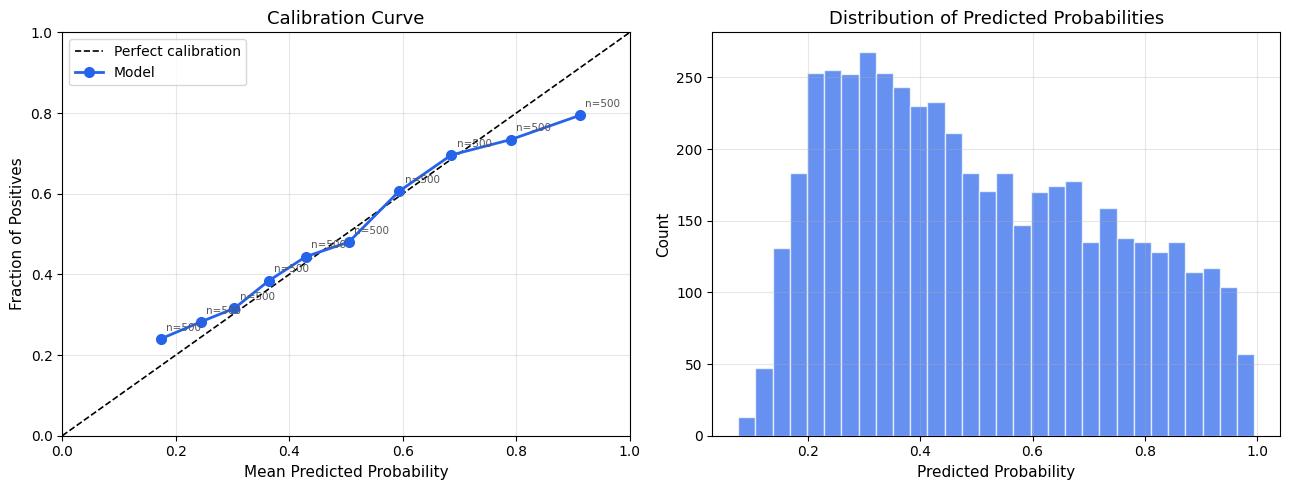

checking calibration for subset ['V342', 'V215', 'V380', 'V191', 'V160']
Bin  1 | n= 494 | mean_pred=0.304 | frac_pos=0.257
Bin  2 | n= 506 | mean_pred=0.345 | frac_pos=0.320
Bin  3 | n= 499 | mean_pred=0.375 | frac_pos=0.395
Bin  4 | n= 498 | mean_pred=0.409 | frac_pos=0.396
Bin  5 | n= 503 | mean_pred=0.445 | frac_pos=0.431
Bin  6 | n= 500 | mean_pred=0.489 | frac_pos=0.490
Bin  7 | n= 500 | mean_pred=0.541 | frac_pos=0.574
Bin  8 | n= 500 | mean_pred=0.602 | frac_pos=0.618
Bin  9 | n= 500 | mean_pred=0.674 | frac_pos=0.688
Bin 10 | n= 500 | mean_pred=0.795 | frac_pos=0.806


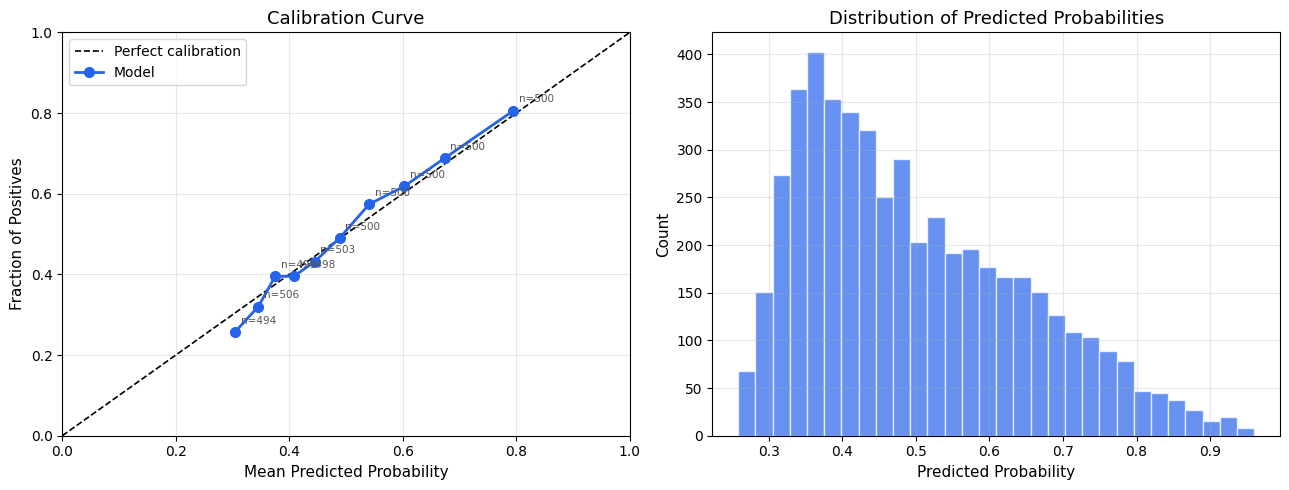

checking calibration for subset ['V342', 'V215', 'V255', 'V191', 'V160']
Bin  1 | n= 500 | mean_pred=0.248 | frac_pos=0.276
Bin  2 | n= 500 | mean_pred=0.306 | frac_pos=0.336
Bin  3 | n= 500 | mean_pred=0.349 | frac_pos=0.372
Bin  4 | n= 500 | mean_pred=0.390 | frac_pos=0.396
Bin  5 | n= 500 | mean_pred=0.438 | frac_pos=0.398
Bin  6 | n= 500 | mean_pred=0.491 | frac_pos=0.502
Bin  7 | n= 500 | mean_pred=0.555 | frac_pos=0.530
Bin  8 | n= 500 | mean_pred=0.628 | frac_pos=0.660
Bin  9 | n= 500 | mean_pred=0.719 | frac_pos=0.720
Bin 10 | n= 500 | mean_pred=0.853 | frac_pos=0.786


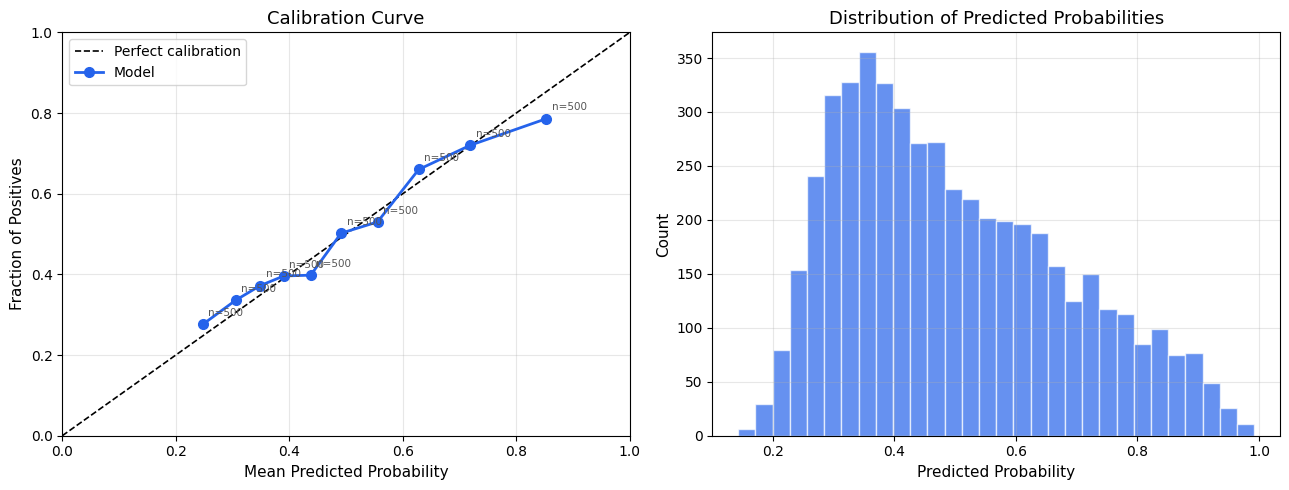

checking calibration for subset ['V342', 'V215', 'V380', 'V255', 'V160']
Bin  1 | n= 500 | mean_pred=0.302 | frac_pos=0.298
Bin  2 | n= 500 | mean_pred=0.342 | frac_pos=0.328
Bin  3 | n= 500 | mean_pred=0.374 | frac_pos=0.366
Bin  4 | n= 500 | mean_pred=0.407 | frac_pos=0.406
Bin  5 | n= 500 | mean_pred=0.446 | frac_pos=0.400
Bin  6 | n= 500 | mean_pred=0.489 | frac_pos=0.496
Bin  7 | n= 500 | mean_pred=0.539 | frac_pos=0.534
Bin  8 | n= 500 | mean_pred=0.601 | frac_pos=0.638
Bin  9 | n= 500 | mean_pred=0.674 | frac_pos=0.726
Bin 10 | n= 500 | mean_pred=0.800 | frac_pos=0.784


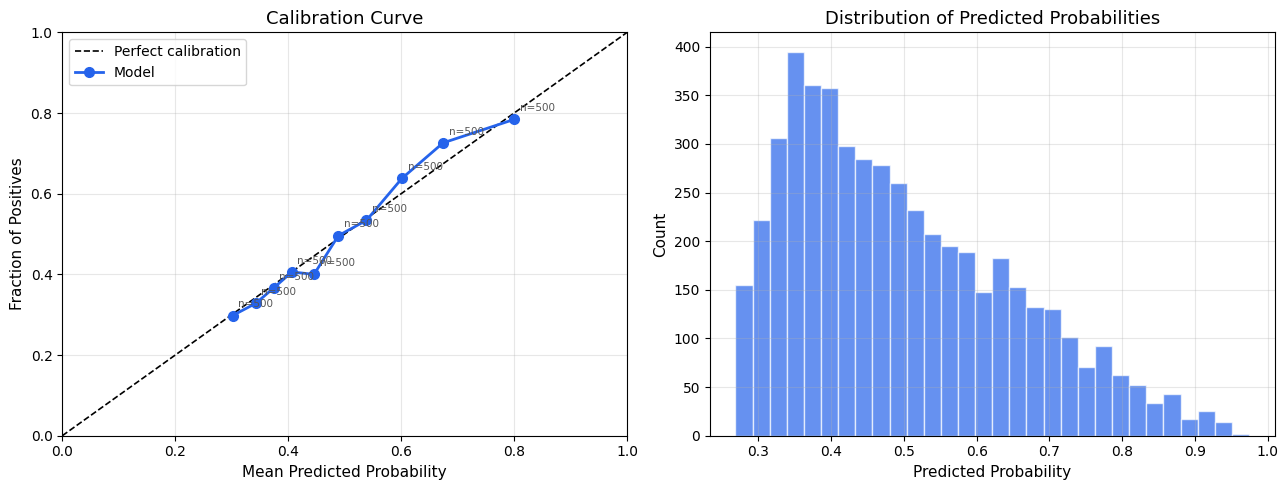

checking calibration for subset ['V342', 'V215', 'V380', 'V255', 'V160', 'V176']
Bin  1 | n= 500 | mean_pred=0.196 | frac_pos=0.306
Bin  2 | n= 500 | mean_pred=0.269 | frac_pos=0.316
Bin  3 | n= 500 | mean_pred=0.319 | frac_pos=0.350
Bin  4 | n= 500 | mean_pred=0.369 | frac_pos=0.384
Bin  5 | n= 500 | mean_pred=0.427 | frac_pos=0.418
Bin  6 | n= 500 | mean_pred=0.493 | frac_pos=0.486
Bin  7 | n= 500 | mean_pred=0.572 | frac_pos=0.600
Bin  8 | n= 500 | mean_pred=0.665 | frac_pos=0.616
Bin  9 | n= 500 | mean_pred=0.771 | frac_pos=0.722
Bin 10 | n= 500 | mean_pred=0.901 | frac_pos=0.778


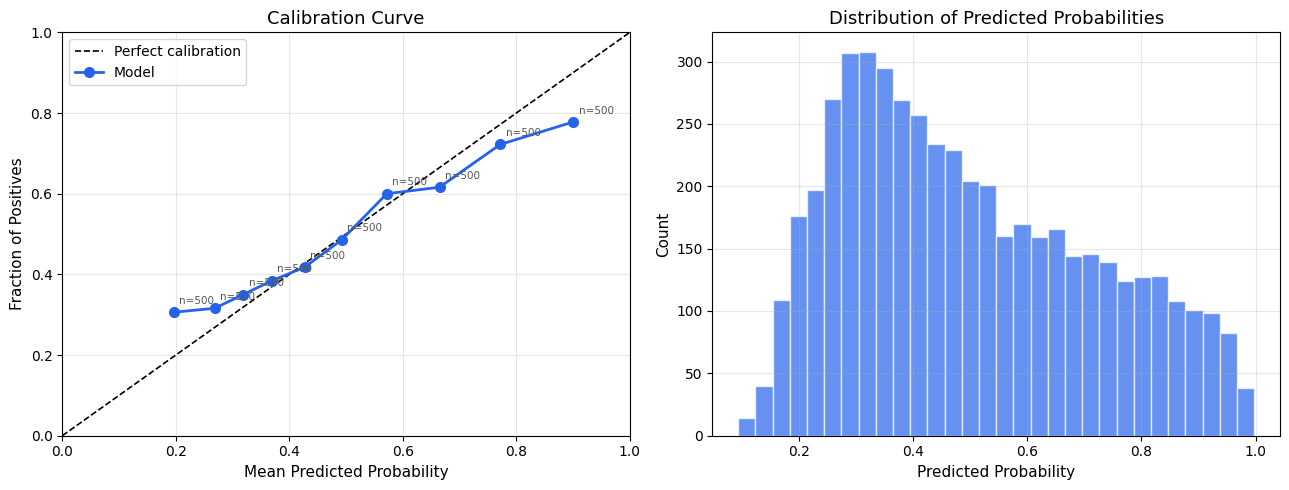

checking calibration for subset ['V215', 'V380', 'V255', 'V191', 'V160', 'V176']
Bin  1 | n= 500 | mean_pred=0.192 | frac_pos=0.284
Bin  2 | n= 500 | mean_pred=0.259 | frac_pos=0.270
Bin  3 | n= 500 | mean_pred=0.312 | frac_pos=0.360
Bin  4 | n= 500 | mean_pred=0.369 | frac_pos=0.372
Bin  5 | n= 500 | mean_pred=0.433 | frac_pos=0.460
Bin  6 | n= 500 | mean_pred=0.505 | frac_pos=0.484
Bin  7 | n= 500 | mean_pred=0.585 | frac_pos=0.600
Bin  8 | n= 500 | mean_pred=0.672 | frac_pos=0.654
Bin  9 | n= 500 | mean_pred=0.777 | frac_pos=0.692
Bin 10 | n= 500 | mean_pred=0.903 | frac_pos=0.800


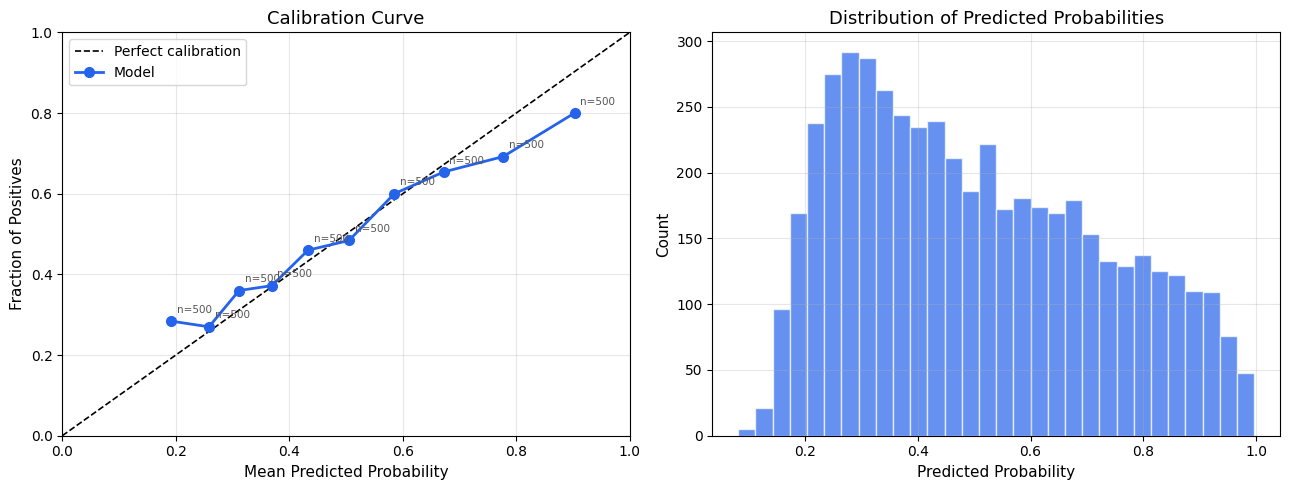

checking calibration for subset ['V342', 'V215', 'V380', 'V255', 'V191', 'V176']
Bin  1 | n= 500 | mean_pred=0.229 | frac_pos=0.248
Bin  2 | n= 500 | mean_pred=0.290 | frac_pos=0.310
Bin  3 | n= 500 | mean_pred=0.338 | frac_pos=0.330
Bin  4 | n= 500 | mean_pred=0.385 | frac_pos=0.420
Bin  5 | n= 500 | mean_pred=0.436 | frac_pos=0.428
Bin  6 | n= 500 | mean_pred=0.495 | frac_pos=0.506
Bin  7 | n= 499 | mean_pred=0.565 | frac_pos=0.559
Bin  8 | n= 501 | mean_pred=0.646 | frac_pos=0.671
Bin  9 | n= 500 | mean_pred=0.737 | frac_pos=0.720
Bin 10 | n= 500 | mean_pred=0.862 | frac_pos=0.784


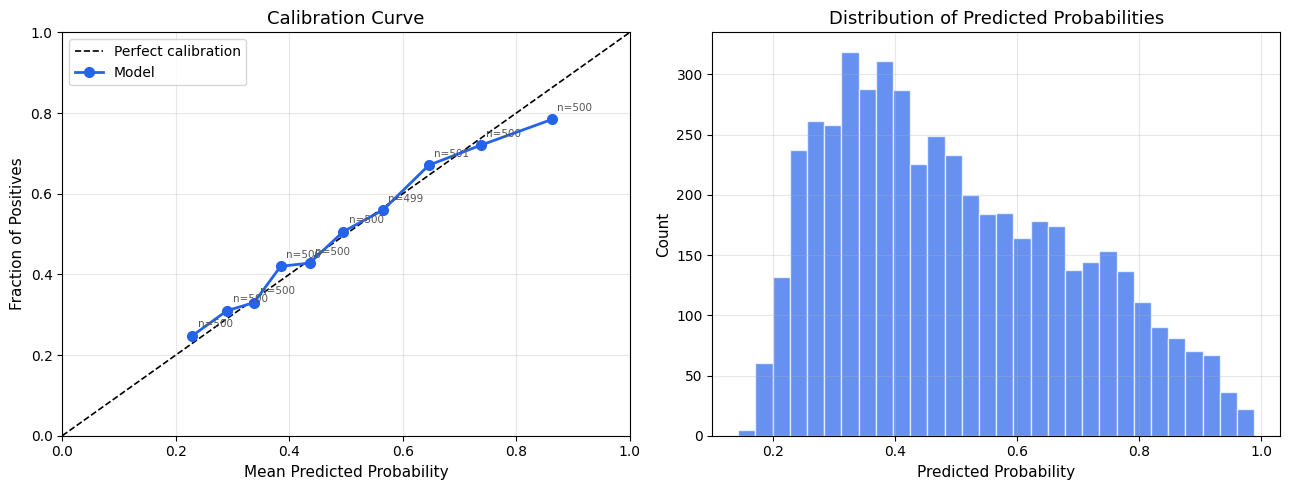

checking calibration for subset ['V215', 'V380', 'V255', 'V191']
Bin  1 | n= 499 | mean_pred=0.319 | frac_pos=0.275
Bin  2 | n= 501 | mean_pred=0.354 | frac_pos=0.345
Bin  3 | n= 496 | mean_pred=0.381 | frac_pos=0.407
Bin  4 | n= 504 | mean_pred=0.409 | frac_pos=0.435
Bin  5 | n= 500 | mean_pred=0.445 | frac_pos=0.464
Bin  6 | n= 498 | mean_pred=0.487 | frac_pos=0.478
Bin  7 | n= 501 | mean_pred=0.529 | frac_pos=0.491
Bin  8 | n= 501 | mean_pred=0.588 | frac_pos=0.613
Bin  9 | n= 500 | mean_pred=0.667 | frac_pos=0.690
Bin 10 | n= 500 | mean_pred=0.798 | frac_pos=0.778


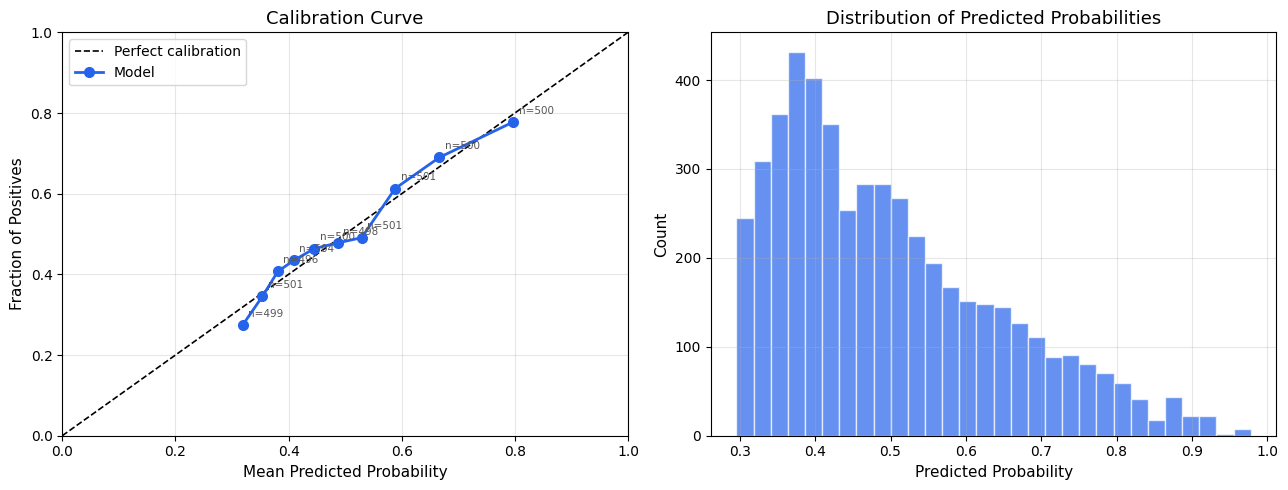

In [33]:
for ind in top10_subset_indices:
    print(f"checking calibration for subset {top10_hyperparameter_tuning_result_dict[ind]['subset_list']}")
    model=XGBClassifier(max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'])
    all_y_test,all_y_prob=get_cv_calibration_predictions(model,x.loc[:,top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y)
    check_calibration(all_y_prob,all_y_test,savename=Path(PLOT_DIR / f"calibration_for_subset_{ind}"))
    print("===============================================")